# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emaanzehra/FlyRank-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The ranked action queue prioritizes pages by their baseline score: stale_visible_page pages (not updated in 15 or fewer active days but still receiving impressions) are flagged for refresh_review. The reason code tells the reviewer exactly why the page appeared: it has observable search demand but has not been updated recently, making it a candidate for content refresh. Pages are ordered highest score first so a reviewer always starts with the highest-impact candidate.

In [1]:
import os
os.environ["HF_TOKEN"] = __import__("google.colab", fromlist=["userdata"]).userdata.get("HF_TOKEN")
import duckdb, pandas as pd, numpy as np, os, pathlib

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")
REL = "hf://datasets/FlyRank/internship-warehouse"

df = con.sql(f"""
SELECT content_hash_id,
       client_hash_id,
       AVG(gsc_impressions) as avg_impressions,
       AVG(gsc_avg_position) as avg_position,
       AVG(gsc_clicks) as avg_clicks,
       COUNT(DISTINCT report_date) as days_with_data,
       MAX(gsc_impressions) as max_impressions
FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')
WHERE (gsc_impressions IS NOT NULL) IS TRUE
GROUP BY content_hash_id, client_hash_id
""").df()

df["stale"] = (df["days_with_data"] <= 15).astype(int)
df["visible"] = (df["avg_impressions"] >= 10).astype(int)
df["baseline_score"] = df["stale"] * df["visible"] * df["avg_impressions"]
df["reason_code"] = ""
df.loc[(df["stale"]==1) & (df["visible"]==1), "reason_code"] = "stale_visible_page"
df["action"] = ""
df.loc[df["reason_code"]=="stale_visible_page", "action"] = "refresh_review"
df["confidence"] = "medium"
df.loc[df["baseline_score"] > 500, "confidence"] = "high"

queue = df[df["action"]=="refresh_review"].sort_values("baseline_score", ascending=False)
print(f"Total pages in queue: {len(queue):,}")
print(f"High confidence: {(queue['confidence']=='high').sum():,}")
print(queue[["content_hash_id","baseline_score","reason_code","action","confidence"]].head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total pages in queue: 641
High confidence: 5
                 content_hash_id  baseline_score         reason_code  \
160460  content_0c11901fc5d75ff9      861.846154  stale_visible_page   
326530  content_e91de019c0c07462      620.076923  stale_visible_page   
327678  content_6af00a7fbd3def79      539.769231  stale_visible_page   
160695  content_35868bbe5afbce53      514.307692  stale_visible_page   
160887  content_0fe39356beb1411a      504.769231  stale_visible_page   
326368  content_779394c90b8743ae      483.384615  stale_visible_page   
326756  content_ad53d798d53b98a6      426.384615  stale_visible_page   
160661  content_ea6db3ecfe821513      374.461538  stale_visible_page   
326366  content_5adb95135ab735e0      355.307692  stale_visible_page   
326743  content_b09ffe56d1bbf3af      323.000000  stale_visible_page   

                action confidence  
160460  refresh_review       high  
326530  refresh_review       high  
327678  refresh_review       high  
160695  refresh_re

## 2. Intended use and limits

This playbook is intended for content strategists and SEO managers who need to decide which pages to review first. It is valid when the data covers at least one full month of search performance. It stops being valid when: the page was recently republished without a metadata date change (staleness signal becomes misleading); impressions came from a single spike rather than sustained traffic (visibility signal becomes inflated); the content is intentionally evergreen and needs no update; or the client has less than 30 days of tracking history in the data.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Before acting on any recommendation, a human reviewer must check: whether the page was recently updated through a channel not reflected in the data; whether the drop in active days is explained by seasonality or a known external event; whether a related page on the same site absorbed the traffic instead. The no-go list: never automate content deletion based on this score alone; never use this score to make promises about traffic recovery; never apply refresh actions to pages that are under active editorial review; never act on pages with fewer than 5 average impressions.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers
The recommendations should be treated as stale and the model should be retrained when: the average Precision@50 on a fresh month drops more than 10 points below the baseline established in Week 4; a new month of warehouse data shows a significantly different distribution of active days per page; a content team reports that more than 30% of reviewed pages turned out to be false positives; or more than 3 months have passed since the last training run.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue written: 641 rows
Metrics saved:
{
  "total_pages_reviewed": 331437,
  "pages_flagged": 641,
  "high_confidence": 5,
  "medium_confidence": 636,
  "top_score": 861.8461538461538,
  "mean_score": 52.80151366227809
}


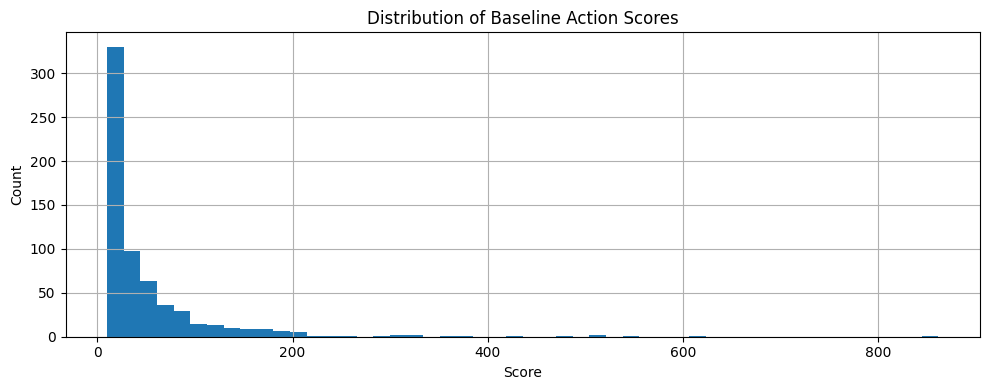

Figure saved to work/figures/score_distribution.png


In [5]:
import pathlib, json

pathlib.Path("work/outputs").mkdir(parents=True, exist_ok=True)
pathlib.Path("work/figures").mkdir(parents=True, exist_ok=True)

queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Queue written: {len(queue)} rows")

metrics = {
    "total_pages_reviewed": len(df),
    "pages_flagged": len(queue),
    "high_confidence": int((queue["confidence"]=="high").sum()),
    "medium_confidence": int((queue["confidence"]=="medium").sum()),
    "top_score": float(queue["baseline_score"].max()),
    "mean_score": float(queue["baseline_score"].mean())
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved:")
print(json.dumps(metrics, indent=2))

import matplotlib.pyplot as plt
queue["baseline_score"].hist(bins=50, figsize=(10,4))
plt.title("Distribution of Baseline Action Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/score_distribution.png")
plt.show()
print("Figure saved to work/figures/score_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.